
# 🧠 Suicidal Tweet Detection with Transformers

## 📌 About the Project

This project uses **Natural Language Processing (NLP)** and a **Transformer-based neural network** to classify tweets into two categories:

- **Not Suicide post**
- **Potential Suicide post**

The goal is to explore how modern NLP models can understand text and classify potentially concerning language.

## 📊 Dataset

The dataset contains tweets and their corresponding labels.

| Column | Description |
|---|---|
| `Tweet` | Text content of the tweet |
| `Suicide` | Classification label |

The dataset was internally generated for this NLP project.

## 🤖 NLP Approach

Instead of traditional techniques such as TF-IDF, this project uses a **Transformer architecture**.

Main steps:

```text
Raw Tweet
   ↓
Tokenizer
   ↓
Token IDs + Attention Mask
   ↓
Token Embeddings
   ↓
Transformer Neural Network
   ↓
Contextual Representations
   ↓
Classification Head
   ↓
Prediction
```

### 🔹 Tokenization

A Hugging Face tokenizer converts each tweet into **tokens and numerical token IDs** that the neural network can process.

### 🔹 Transformer Model

The project uses:

```python
AutoTokenizer
AutoModelForSequenceClassification
Trainer
TrainingArguments
```

The Transformer learns contextual relationships between words and uses these representations to classify the tweet.

## 📈 Model Evaluation

The model is evaluated using classification metrics such as:

- **F1 Score**
- **Confusion Matrix**
- **Accuracy / Precision / Recall**

## 🛠️ Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Transformers


## ⚠️ Ethical Considerations

This project is intended for **educational and research purposes**. A model prediction cannot determine a person's mental health or actual suicide risk. Real-world applications would require careful consideration of privacy, bias, false positives/negatives, human oversight, and appropriate professional support.

## 🎯 Key Learning

Through this project, I explored the modern NLP pipeline:

**Text → Tokenization → Token IDs → Embeddings → Self-Attention → Contextual Representations → Transformer → Classification**

This project helped me understand how neural networks and Transformer models process and learn from natural language.


```
import the key libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# We already have cleaned the dataset in our previous logestic regression model.

df = pd.read_csv('clean_dataset_tweet_suicide.csv') 
df.sample(5)

,Tweet,Suicide
756,@Mileycyrus i love jesus too and im getting re...,not suicide post
801,@christinamendez: My list is short; so does th...,not suicide post
1418,I feel so lonely,potential suicide post
1261,My cousin ( recently retired 30 years in milit...,potential suicide post
954,i just realized that in a month i can celebrat...,not suicide post


In [51]:
df['Suicide'] = df['Suicide'].map({'not suicide post':0, 'potential suicide post':1})

In [52]:
df = df.rename(columns={'Tweet':'text', 'Suicide':'label'})

In [53]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

In [54]:
dataset = Dataset.from_pandas(df[['text','label']])
dataset = dataset.train_test_split(test_size=0.3, seed=101)

In [55]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1211
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 519
    })
})

In [56]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [57]:
model_name = 'distilBERT-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [58]:
def tokenizer_func(data):
    return tokenizer(data['text'], padding='max_length', truncation=True, max_length=64)

In [59]:
tokenized_data = dataset.map(tokenizer_func, batched=True)

Map:   0%|          | 0/1211 [00:00<?, ? examples/s]

Map:   0%|          | 0/519 [00:00<?, ? examples/s]

In [60]:
tokenized_data

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1211
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 519
    })
})

In [61]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= 2)

training_args = TrainingArguments(
    output_dir='./result',
    
    num_train_epochs = 3,
    per_device_train_batch_size =8,
    per_device_eval_batch_size = 15,
    
    learning_rate = 5e-5,
    
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    save_total_limit = 1,
    logging_steps = 100,
    
    load_best_model_at_end = True,
    metric_for_best_model = 'f1_macro',
    greater_is_better = True,
    dataloader_pin_memory=False,
    seed = 101,
    report_to='none' 
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilBERT-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [62]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [69]:
def metrics(eval_pred):
    predictions = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(predictions, axis=1)
    return {
        'f1_macro':f1_score(
            labels,
            predictions,
            average='macro'
        )
    }

In [70]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized_data['train'],
    eval_dataset = tokenized_data['test'],
    compute_metrics = metrics
)

In [71]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.062630,0.337491,0.939102
2,0.023793,0.327517,0.952417
3,0.002537,0.333128,0.952619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=456, training_loss=0.02811240103134575, metrics={'train_runtime': 104.7349, 'train_samples_per_second': 34.688, 'train_steps_per_second': 4.354, 'total_flos': 60156757414656.0, 'train_loss': 0.02811240103134575, 'epoch': 3.0})

In [73]:
pred = trainer.predict(
    tokenized_data['test']
)

pred_labels = np.argmax(
    pred.predictions,
    axis=1
)

true_labels = pred.label_ids

                        precision    recall  f1-score   support

      not suicide post       0.97      0.96      0.96       326
potential suicide post       0.94      0.94      0.94       193

              accuracy                           0.96       519
             macro avg       0.95      0.95      0.95       519
          weighted avg       0.96      0.96      0.96       519



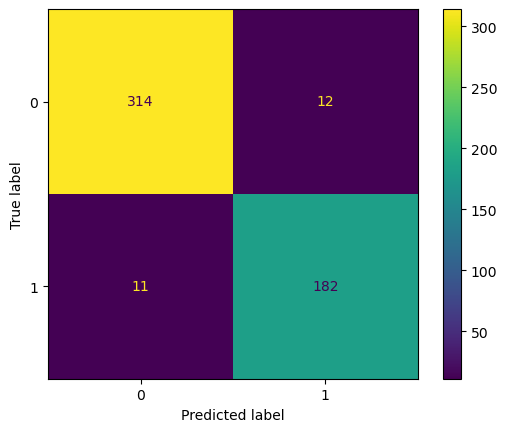

In [74]:
print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=[
            'not suicide post',
            'potential suicide post'
        ]
    )
)

cm = confusion_matrix(true_labels,pred_labels)
dis = ConfusionMatrixDisplay(confusion_matrix=cm)
dis.plot();

```
Compare to our logestic regression model, we have done more better prediction using transformers.
97% precesion for not suicide post and 94% for potential suicide post with accuracy of 96% is awesome.

In [81]:
def predict_sentiment(message):

    tok_message = tokenizer(
        message,
        truncation=True,
        max_length=64
    )

    message_dataset = Dataset.from_dict({
        "input_ids": [tok_message["input_ids"]],
        "attention_mask": [tok_message["attention_mask"]]
    })

    prediction = trainer.predict(message_dataset)

    predicted_label = np.argmax(
        prediction.predictions,
        axis=1
    )[0]

    label_map = {
        0: "not suicide post",
        1: "potential suicide post"
    }

    return label_map[predicted_label]

In [92]:
predict_sentiment('i lovethe world')

'not suicide post'

In [84]:
predict_sentiment('I do not know how to continue')

'not suicide post'

In [85]:
predict_sentiment('I want to die')

'potential suicide post'

In [91]:
predict_sentiment('I will destroy myself')

'potential suicide post'